### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from hydra import compose, initialize
from pathlib import Path
from omegaconf import OmegaConf

initialize(config_path="../config", version_base="1.3")
cfg = compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

sys.path.insert(0, str(cfg.paths.project_root))

from src.activation_recorder import MultiPromptActivations
from src.time_series_activations import MultiPromptTimeSeries
from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries


paths:
  project_root: /home/p84400019/projects/consciousness-llms/IT-LLMs/
  model_path: ${model.company}/${model.model_family}/${model.model_size}/${model.it}/
  activation_method: ${time_series.node_type}/${time_series.node_activation}/${time_series.projection_method}/
  phyid_method: ${paths.activation_method}phyid_tau-${phyid.tau}/phyid_kind-${phyid.kind}/phyid_redundancy-${phyid.redundancy}/
  data_dir: ${paths.project_root}data/${paths.model_path}${generation.name}/
  data_activations_dir: ${paths.data_dir}activations/
  data_activations_file: ${paths.data_activations_dir}multi_prompt_activations.pkl
  data_phyid_dir: ${paths.data_dir}phyid/${paths.phyid_method}
  data_phyid_file: ${paths.data_phyid_dir}multi_prompt_phyid.pkl
  data_phyid_file_data_array: ${paths.data_phyid_dir}multi_prompt_phyid.nc
  plot_dir: ${paths.project_root}plots/${paths.model_path}${generation.name}/
  plot_time_series_dir: ${paths.plot_dir}time_series/${paths.activation_method}
  plot_phyid_dir: ${path

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Time Series Loading

In [2]:
data_activations_file = cfg.paths.data_activations_file
activations = MultiPromptActivations.load(file_path=data_activations_file)

MultiPromptActivations successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/3B/random/base_prompt/activations/multi_prompt_activations.pkl'.


In [3]:
time_series = MultiPromptTimeSeries.from_activations(
    activations, 
    node_type=cfg.time_series.node_type,
    node_activation=cfg.time_series.node_activation,
    projection_method=cfg.time_series.projection_method, 
    exclude_shared_expert_moe=cfg.time_series.exclude_shared_expert_moe, 
)
time_series.plot(token_x=True, ticks_all_layers=True, plot_dir=cfg.paths.plot_time_series_dir)

Prompt 0 has 128 generated tokens: ['bam', ' Medicine', ' obsolete', 'iclass', ' brushing', ' Tahoe', '("\n', '�', ' *)__', 'unities', '505', '\ttr', 'olec', 'ài', 'ToDelete', ' quite', ' Wikispecies', 'вердж', ' exercitation', 'ества', 'ेय', ' crowned', 'irq', ' uncon', ' chancellor', 'rypto', 'Д', ' Raptors', ' devoid', '注册', ' literally', '续', 'akens', ' Target', '항', '/km', ' Vas', '.help', 'forcement', ' Sử', 'อาร', ' hoop', 'bk', ' Du', '.getAction', 'σκε', '891', 'Percentage', ' Boundary', 'ується', ' ave', ' Doesn', '_DM', ' distint', ' Quartz', ' kém', ' Ther', 'ánt', 'ulen', ' closing', '\tdocument', 'tweet', ' 용', 'セット', ',opt', ' tarihinde', ' discs', ' professionalism', ' Classified', ' 싸', ' Marvel', ' How', 'cak', 'PRIVATE', ' pairing', 'NDER', '人人', '.FindGameObjectWithTag', ' Knowledge', '.Argument', 'FormData', ' divergence', ' seus', 'กลาง', ' 누구', '지', ' مط', ' PACKAGE', ' Boris', ' sadece', 'Cx', '.FileWriter', 'ець', "')],\n", ' центр', '신', 'Importer', 'Dies', ' 

/home/p84400019/projects/consciousness-llms/IT-LLMs/src/time_series_activations/MultiPromptTimeSeries.py:223: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.98])   # leave 8 % of the height free on top
/home/p84400019/projects/consciousness-llms/IT-LLMs/src/time_series_activations/MultiPromptTimeSeries.py:223: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=[0, 0, 1, 0.98])   # leave 8 % of the height free on top
/home/p84400019/projects/consciousness-llms/IT-LLMs/src/time_series_activations/MultiPromptTimeSeries.py:223: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.tight_layout(rect=[0, 0, 1, 0.98])   # leave 8 % of the height free on top
/home/p84400019/projects/consciousness-llms/IT-LLMs/src/time_series_activations/MultiPromptTimeSeries.py:223: UserWarning: Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.tight_l

Time-series plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/time_series/attention/attention_outputs/norm//prompt_0/time_series.png


### PhyID Decomposition

In [4]:
compute_phyid = True
data_phyid_path = cfg.paths.data_phyid_dir

if compute_phyid:
    phyid_comp = MultiPromptPhyID.from_time_series(
        time_series,
        cfg.phyid.tau,
        cfg.phyid.kind,
        cfg.phyid.redundancy
    ) 
    phyid_comp.save(dir_path=data_phyid_path)

Processing prompt 1/1 with 128 generated tokens.
[ETA] 1/450912 done | avg=0.021s | ETA ≈ 2:36:37
[ETA] 10/450912 done | avg=0.006s | ETA ≈ 0:41:48
[ETA] 100/450912 done | avg=0.003s | ETA ≈ 0:19:37
[ETA] 1000/450912 done | avg=0.002s | ETA ≈ 0:18:25
[ETA] 10000/450912 done | avg=0.003s | ETA ≈ 0:19:43
[ETA] 100000/450912 done | avg=0.002s | ETA ≈ 0:14:35
[ETA] 450912/450912 done | avg=0.003s | ETA ≈ 0:00:00
PromptPhyID successfully saved to '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/prompt_000.pkl'.
MultiPromptPhyID successfully saved to directory '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/'.


In [5]:
print(f"Loading phyid from {data_phyid_path}")
phyid = MultiPromptPhyID.load(dir_path=data_phyid_path)
print("Building data array for phyid")
phyid.build_data_array()
print("Computing average prompt phyid")
phyid = phyid.compute_average_prompt_phyid(save_dir_path=cfg.paths.data_phyid_dir)

Loading phyid from /home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/
PromptPhyID successfully loaded from '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/prompt_000.pkl'.
MultiPromptPhyID loaded from directory: /home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/
Building data array for phyid
Computing average prompt phyid
Processing source layer 0...
Processing source layer 1...
Processing source layer 2...
Processing source layer 3...
Processing source layer 4...
Processing source layer 5...
Processing source layer 6...
Processing source layer 7...
Processing source layer 8...
Processing

PicklingError: Can't pickle <class 'src.phyid_decomposition.PhyIDTimeSeries.PhyIDTimeSeries'>: it's not the same object as src.phyid_decomposition.PhyIDTimeSeries.PhyIDTimeSeries

In [8]:
phyid = phyid.prompts[0]

In [ ]:
phyid.plot_syn_minus_red_rank("syn_minus_red_rank")
phyid.syn_rank_minus_red_rank
phyid.plot_syn_minus_red_rank("syn_rank_minus_red_rank")

In [9]:
phyid.compute_extra_atoms()
phyid.build_data_array()

<xarray.DataArray 'phiid' (atom: 56, source_layer: 28, source_node: 24,
                           target_layer: 28, target_node: 24, time: 127)> Size: 13GB
array([[[[[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
             0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
           [-6.59550577e-02, -1.01473495e-01,  8.95040035e-02, ...,
             7.08973259e-02, -1.46191895e-01, -9.78290141e-02],
           [ 9.30865854e-03, -4.48134243e-02, -3.21142450e-02, ...,
            -4.30823714e-02, -2.99930423e-02,  4.30471823e-03],
           ...,
           [ 6.74471818e-03,  1.88475326e-02, -3.85475159e-03, ...,
             3.26381847e-02, -6.58978010e-03,  9.14800726e-03],
           [-5.42004779e-02,  1.25420317e-01,  1.27698675e-01, ...,
             8.93566012e-03,  1.06253400e-01,  3.87341268e-02],
           [-2.54072472e-02, -1.16000921e-01,  5.32168970e-02, ...,
             1.66796781e-02, -7.96890073e-03,  2.62459442e-02]],

          [[-2.93920226e-02,  6.38163462e-02,  6.32569492e-02, ...,
             8.27367157e-02,  4.93396074e-05, -1.93790682e-02],
           [ 3.51795405e-02, -2.34084636e-01,  2.09064245e-01, ...,
             3.02581191e-01,  2.74471343e-02, -8.11706632e-02],
           [ 8.24991614e-02,  3.58776271e-01,  2.58398026e-01, ...,
            -2.68858999e-01, -5.54494113e-02, -3.84686962e-02],
...
             1.06128323e+00,  4.13478352e-02,  7.36447349e-02],
           [-0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
             0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
           [-0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
             0.00000000e+00, -0.00000000e+00,  0.00000000e+00]],

          [[-9.01969612e-01,  6.87282801e-01, -4.83471155e-01, ...,
             4.73142862e-01, -3.67508024e-01,  8.45721141e-02],
           [-0.00000000e+00, -0.00000000e+00,  0.00000000e+00, ...,
             0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
           [-0.00000000e+00,  0.00000000e+00, -0.00000000e+00, ...,
             0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
           ...,
           [-0.00000000e+00, -0.00000000e+00,  0.00000000e+00, ...,
             0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
           [-9.62698180e-03,  5.11670768e-01,  3.01504105e-01, ...,
             1.96003332e-03,  1.22430646e+00, -1.35297763e+00],
           [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
             0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]]]]],
      dtype=float32)
Coordinates:
  * atom          (atom) <U56 13kB 'causal_density' ... 'yty_normalized'
  * source_layer  (source_layer) int64 224B 0 1 2 3 4 5 6 ... 22 23 24 25 26 27
  * source_node   (source_node) int64 192B 0 1 2 3 4 5 6 ... 18 19 20 21 22 23
  * target_layer  (target_layer) int64 224B 0 1 2 3 4 5 6 ... 22 23 24 25 26 27
  * target_node   (target_node) int64 192B 0 1 2 3 4 5 6 ... 18 19 20 21 22 23
  * time          (time) int64 1kB 0 1 2 3 4 5 6 ... 120 121 122 123 124 125 126
Attributes:
    model:    meta-llama/Llama-3.2-3B

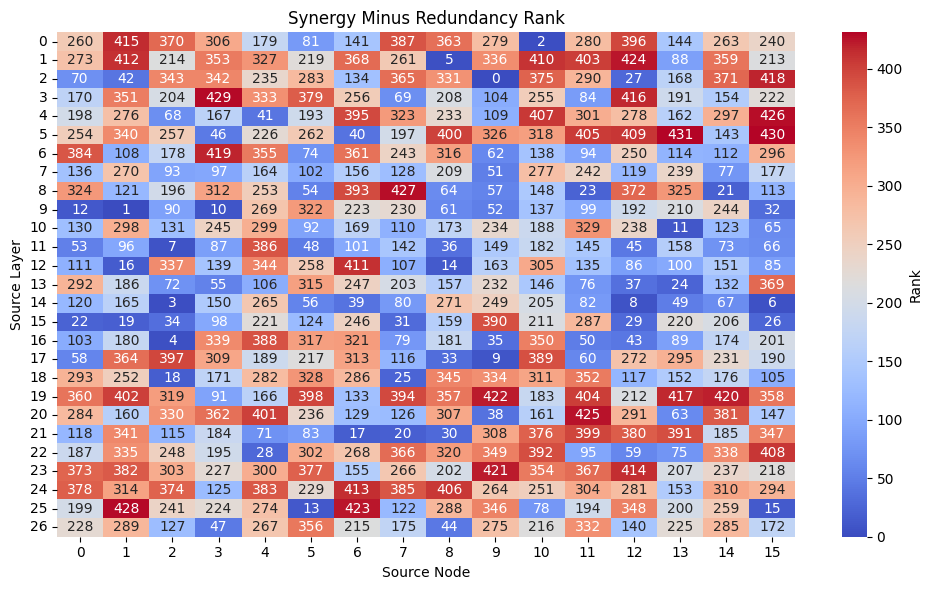

In [16]:
phyid.__dict__.pop("syn_minus_red_rank", None)
phyid.syn_minus_red_rank
phyid.plot_synergy_rank_heatmap()

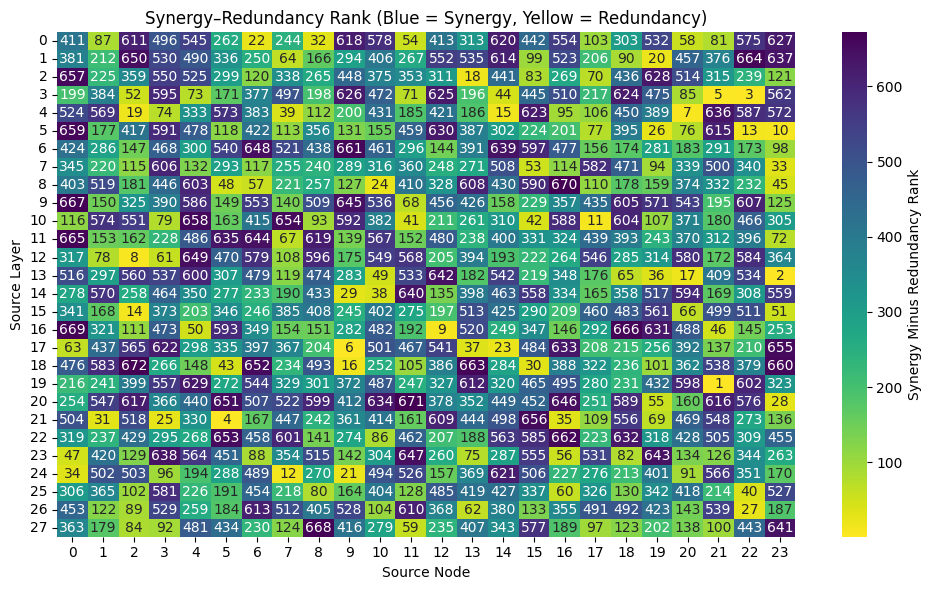

Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/syn_minus_red_rank/rank_plot.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/syn_minus_red_rank/avg_synergy_score_per_layer.png


In [14]:
node_ranking = phyid.syn_minus_red_rank
phyid.plot_syn_minus_red_rank_per_node(node_ranking, plot_dir=cfg.paths.plot_phyid_dir)
phyid.plot_syn_minus_red_rank_per_layer(node_ranking, plot_dir=cfg.paths.plot_phyid_dir)

In [11]:
plot_dir = cfg.paths.plot_phyid_dir

phyid.node_heatmap(atom='sts', plot_dir=plot_dir)
phyid.plot_mean_along('sts', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('syn_minus_red', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('sts_normalized', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('rtr', varying_dim='source_layer', plot_dir=plot_dir)
phyid.plot_mean_along('mutual_information', varying_dim='source_layer', plot_dir=plot_dir)

Heatmap saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/node_heatmap/sts/heatmap.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/sts/source_layer.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/syn_minus_red/source_layer.png
Plot saved to /home/p84400019/projects/consciousness-llms/IT-LLMs/plots/meta/llama-3/3B/random/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/plot_mean_along/sts_normalized/source_layer.png
Plot saved to /home/p84400019/projects/c

### Graph Theoretical Analysis

In [ ]:
from src.graph_theoretical_analysis import PromptGraphTheoreticalAnalysis

graph_theoretical = PromptGraphTheoreticalAnalysis.from_phyid_data(prompt_phyid=phyid)

In [ ]:
# graph_theoretical.plot_atom_graph(atom='sts')
sge = graph_theoretical.global_efficiency(atom='sts')
smo = graph_theoretical.modularity(atom='sts')
rge = graph_theoretical.global_efficiency(atom='rtr')
rmo = graph_theoretical.modularity(atom='rtr')
print(f"STS Global Efficiency: {sge}, STS Modularity: {smo}")
print(f"RTR Global Efficiency: {rge}, RTR Modularity: {rmo}")

STS Global Efficiency: 0.07378549225262356, STS Modularity: 0.034103109771126294
RTR Global Efficiency: 0.011879988444945878, RTR Modularity: 0.10393579895766247


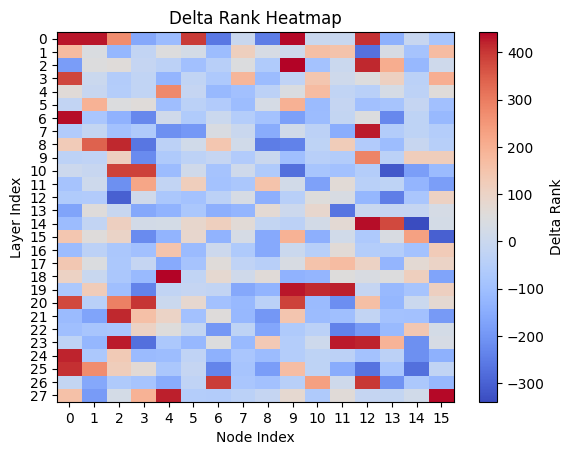

Gateways and Broadcasters: {'nodes': array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 

In [ ]:
gb = graph_theoretical.gateways_and_broadcasters()
print(f"Gateways and Broadcasters: {gb}")